In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("DataCoSupplyChainDataset.csv", encoding='latin1')

In [5]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [7]:
df.shape

(180519, 53)

In [9]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [23]:
selected_columns = [
    'Type',
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Benefit per order',
    'Sales per customer',
    'Delivery Status',
    'Late_delivery_risk',
    'Category Name',
    'Customer Country',
    'Customer Segment',
    'Market',
    'Order City',
    'Order Country',
    'order date (DateOrders)',
    'Order Id',
    'Order Item Discount',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Profit Per Order',
    'Order Region',
    'Order State',
    'Product Name',
    'shipping date (DateOrders)',
    'Shipping Mode'
]

supply_df = df[selected_columns].copy()

supply_df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,...,Order Id,Order Item Discount,Order Item Product Price,Order Item Quantity,Order Profit Per Order,Order Region,Order State,Product Name,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,...,77202,13.110000,327.75,1,91.250000,Southeast Asia,Java Occidental,Smart watch,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,...,75939,16.389999,327.75,1,-249.089996,South Asia,Rajastán,Smart watch,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,...,75938,18.030001,327.75,1,-247.779999,South Asia,Rajastán,Smart watch,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,...,75937,22.940001,327.75,1,22.860001,Oceania,Queensland,Smart watch,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,...,75936,29.500000,327.75,1,134.210007,Oceania,Queensland,Smart watch,1/15/2018 11:24,Standard Class


In [15]:
supply_df.isnull().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Name                    0
Customer Country                 0
Customer Segment                 0
Market                           0
Order City                       0
Order Country                    0
order date (DateOrders)          0
Order Id                         0
Order Item Discount              0
Order Item Product Price         0
Order Item Quantity              0
Order Profit Per Order           0
Order Region                     0
Order State                      0
Product Name                     0
shipping date (DateOrders)       0
Shipping Mode                    0
dtype: int64

In [17]:
supply_df.shape

(180519, 24)

In [19]:
supply_df.duplicated().sum()

0

In [25]:
supply_df['order date (DateOrders)'] = pd.to_datetime(
    supply_df['order date (DateOrders)']
)

supply_df['shipping date (DateOrders)'] = pd.to_datetime(
    supply_df['shipping date (DateOrders)']
)

In [27]:
supply_df['Order Year'] = supply_df['order date (DateOrders)'].dt.year
supply_df['Order Month'] = supply_df['order date (DateOrders)'].dt.month_name()
supply_df['Order Day'] = supply_df['order date (DateOrders)'].dt.day
supply_df['Order Quarter'] = supply_df['order date (DateOrders)'].dt.quarter

In [29]:
supply_df['Shipping Delay'] = (
    supply_df['Days for shipping (real)']
    - supply_df['Days for shipment (scheduled)']
)

supply_df['Inventory Value'] = (
    supply_df['Order Item Quantity']
    * supply_df['Order Item Product Price']
)

supply_df['Profit Margin %'] = (
    supply_df['Order Profit Per Order']
    / supply_df['Sales per customer']
) * 100

In [31]:
supply_df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,...,Product Name,shipping date (DateOrders),Shipping Mode,Order Year,Order Month,Order Day,Order Quarter,Shipping Delay,Inventory Value,Profit Margin %
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,...,Smart watch,2018-02-03 22:56:00,Standard Class,2018,January,31,1,-1,327.75,29.001397
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,...,Smart watch,2018-01-18 12:27:00,Standard Class,2018,January,13,1,1,327.75,-80.000645
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,...,Smart watch,2018-01-17 12:06:00,Standard Class,2018,January,13,1,0,327.75,-80.001291
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,...,Smart watch,2018-01-16 11:45:00,Standard Class,2018,January,13,1,-1,327.75,7.499754
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,...,Smart watch,2018-01-15 11:24:00,Standard Class,2018,January,13,1,-2,327.75,44.999164


In [33]:
supply_df.shape

(180519, 31)

In [35]:
supply_df.to_csv("supply_chain_cleaned.csv", index=False)

In [37]:
import sqlite3

In [39]:
conn = sqlite3.connect("supply_chain.db")

In [41]:
supply_df.to_sql(
    "supply_chain_data",
    conn,
    if_exists="replace",
    index=False
)

180519

In [45]:
query = """
SELECT
    Market,
    ROUND(SUM([Order Profit Per Order]), 2) AS Total_Profit
FROM supply_chain_data
GROUP BY Market
ORDER BY Total_Profit DESC
"""

pd.read_sql(query, conn)

,Market,Total_Profit
0,Europe,1169442.96
1,LATAM,1123321.61
2,Pacific Asia,857753.44
3,USCA,564313.78
4,Africa,252071.18


In [47]:
top_products = supply_df.groupby("Product Name")["Order Profit Per Order"] \
.sum() \
.sort_values(ascending=False) \
.head(10)

top_products

Product Name
Field & Stream Sportsman 16 Gun Fire Safe        756220.767190
Perfect Fitness Perfect Rip Deck                 493828.299782
Diamondback Women's Serene Classic Comfort Bi    427455.568106
Nike Men's Free 5.0+ Running Shoe                379915.818503
Nike Men's Dri-FIT Victory Golf Polo             350421.029567
Pelican Sunstream 100 Kayak                      324076.370020
O'Brien Men's Neoprene Life Vest                 318451.430554
Nike Men's CJ Elite 2 TD Football Cleat          311902.820214
Under Armour Girls' Toddler Spine Surge Runni    126278.510299
Dell Laptop                                       69656.810171
Name: Order Profit Per Order, dtype: float64

In [49]:
delay_analysis = supply_df.groupby("Shipping Mode")["Late_delivery_risk"] \
.mean() \
.sort_values(ascending=False)

delay_analysis

Shipping Mode
First Class       0.953225
Second Class      0.766328
Same Day          0.457430
Standard Class    0.380717
Name: Late_delivery_risk, dtype: float64

In [51]:
market_sales = supply_df.groupby("Market")["Sales per customer"] \
.sum() \
.sort_values(ascending=False)

market_sales

Market
Europe          9.769198e+06
LATAM           9.235762e+06
Pacific Asia    7.434263e+06
USCA            4.553500e+06
Africa          2.061679e+06
Name: Sales per customer, dtype: float64

In [53]:
monthly_sales = supply_df.groupby("Order Month")["Sales per customer"] \
.sum()

monthly_sales

Order Month
April        2.744816e+06
August       2.864110e+06
December     2.335381e+06
February     2.595053e+06
January      3.109090e+06
July         2.864577e+06
June         2.749136e+06
March        2.807828e+06
May          2.862117e+06
November     2.429193e+06
October      2.851095e+06
September    2.842006e+06
Name: Sales per customer, dtype: float64

In [55]:
category_revenue = supply_df.groupby("Category Name")["Sales per customer"] \
.sum() \
.sort_values(ascending=False)

category_revenue

Category Name
Fishing                 6.226935e+06
Cleats                  3.982857e+06
Camping & Hiking        3.700784e+06
Cardio Equipment        3.320251e+06
Women's Apparel         2.828708e+06
Water Sports            2.798044e+06
Men's Footwear          2.598494e+06
Indoor/Outdoor Games    2.596454e+06
Shop By Sport           1.177186e+06
Computers               5.953950e+05
Electronics             3.333273e+05
Cameras                 2.404967e+05
Garden                  2.317655e+05
Children's Clothing     2.092684e+05
Crafts                  2.007049e+05
Girls' Apparel          1.362068e+05
Women's Clothing        1.260069e+05
Accessories             1.197125e+05
Sporting Goods          1.050636e+05
Golf Gloves             1.047874e+05
Music                   1.016873e+05
Consumer Electronics    9.793756e+04
Golf Shoes              9.650647e+04
Health and Beauty       9.535811e+04
Kids' Golf Clubs        8.947370e+04
Baseball & Softball     8.436727e+04
Boxing & MMA            

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

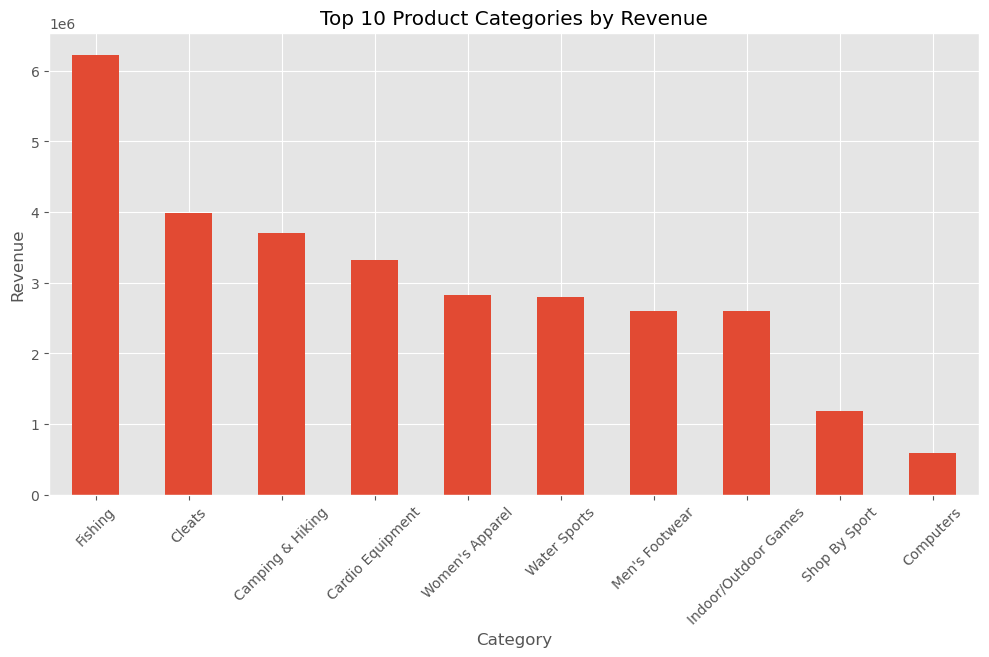

In [61]:
top_categories = category_revenue.head(10)

plt.figure(figsize=(12,6))

top_categories.plot(kind="bar")

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

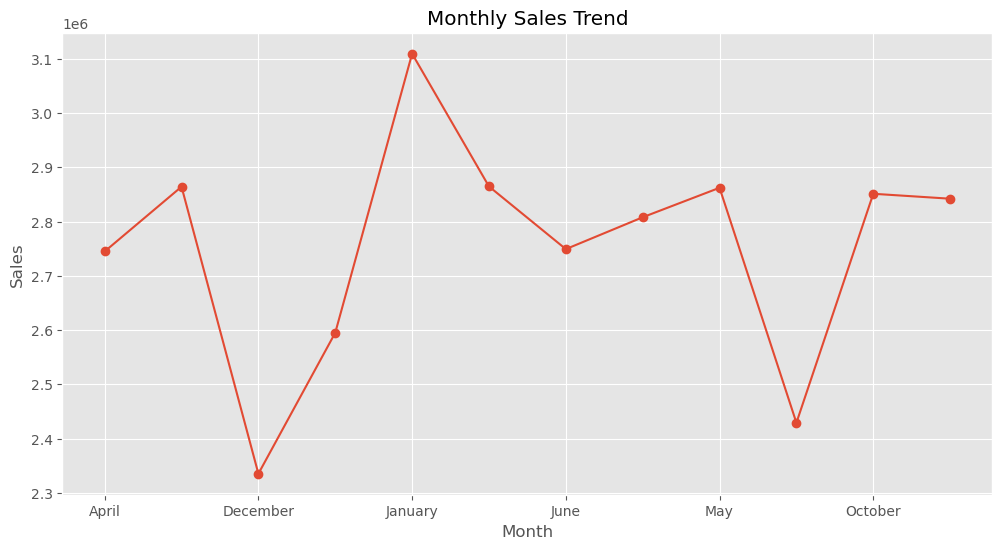

In [63]:
plt.figure(figsize=(12,6))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

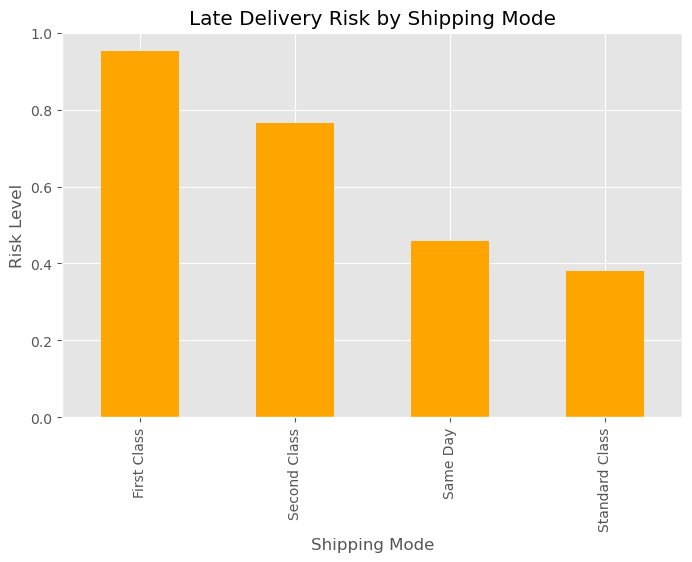

In [65]:
plt.figure(figsize=(8,5))

delay_analysis.plot(kind="bar", color="orange")

plt.title("Late Delivery Risk by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Risk Level")

plt.show()

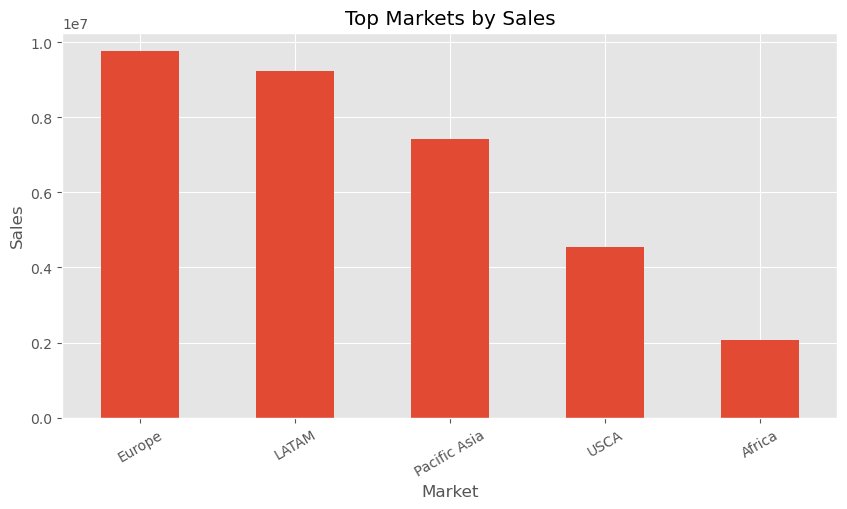

In [67]:
plt.figure(figsize=(10,5))

market_sales.plot(kind="bar")

plt.title("Top Markets by Sales")
plt.xlabel("Market")
plt.ylabel("Sales")

plt.xticks(rotation=30)

plt.show()

In [69]:
plt.savefig("monthly_sales_trend.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [71]:
supply_df.to_csv("supply_chain_final.csv", index=False)

In [73]:
supply_df.to_csv("supply_chain_final.csv", index=False)


In [1]:
import os

for file in os.listdir():
    if "supply_chain" in file:
        print(file)

supply_chain.db
supply_chain_cleaned.csv
supply_chain_final.csv


In [5]:
import pandas as pd

supply_df = pd.read_csv("supply_chain_final.csv")

In [9]:
supply_df.to_excel("supply_chain_final.xlsx", index=False)

In [11]:
import pandas as pd

df = pd.read_csv("supply_chain_final.csv")

print(df.shape)

(180519, 31)


In [ ]:
df.to_excel(
    "supply_chain_final.xlsx",
    index=False,
    engine="openpyxl"
)

In [ ]:
import os

print(os.path.getsize("supply_chain_final.xlsx"))

In [ ]:
df.to_excel(
    "supply_chain_final.xlsx",
    index=False,
    engine="openpyxl"
)

In [ ]:
import openpyxl
print(openpyxl.__version__)

In [ ]:
!pip install openpyxl